Shape: (1048575, 13)

Column dtypes:
 subject_id         object
night_id           object
epoch_index         int64
age                 int64
bmi               float64
acc_mean          float64
acc_std           float64
hr_mean           float64
hr_std            float64
spo2_mean         float64
spo2_min          float64
is_apnea_event      int64
severity_label     object
dtype: object

First 5 rows:
   subject_id  night_id  epoch_index  age   bmi  acc_mean  acc_std  hr_mean  \
0      S0000  S0000_N0            0   60  32.8      5.31     1.36     54.9   
1      S0000  S0000_N0            1   60  32.8      5.70     0.71     53.8   
2      S0000  S0000_N0            2   60  32.8      5.11     1.28     61.3   
3      S0000  S0000_N0            3   60  32.8      5.00     1.28     56.9   
4      S0000  S0000_N0            4   60  32.8      3.56     0.73     57.4   

   hr_std  spo2_mean  spo2_min  is_apnea_event severity_label  
0    2.84       93.5      93.4               0       moderate

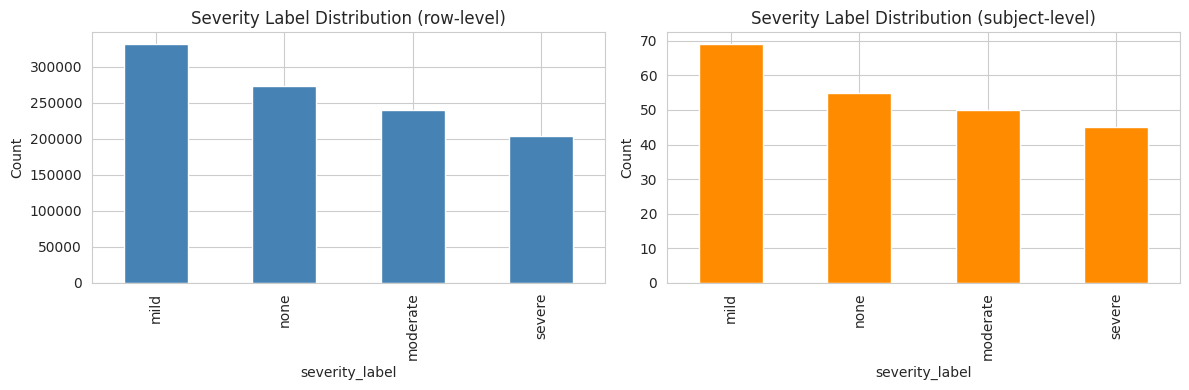


Subjects with more than 1 unique severity_label: 137

is_apnea_event counts:
is_apnea_event
0    854030
1    194545
Name: count, dtype: int64
Apnea event rate: 0.1855


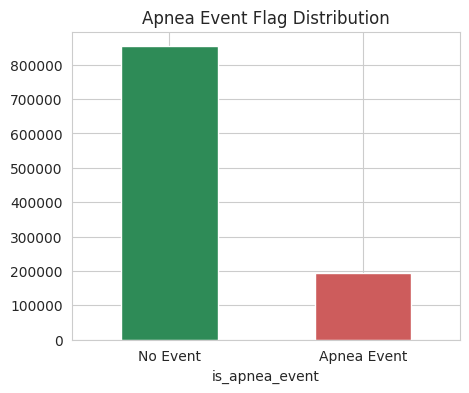


Apnea event rate by severity label:
 severity_label
none        0.027424
mild        0.115830
moderate    0.261225
severe      0.420599
Name: is_apnea_event, dtype: float64


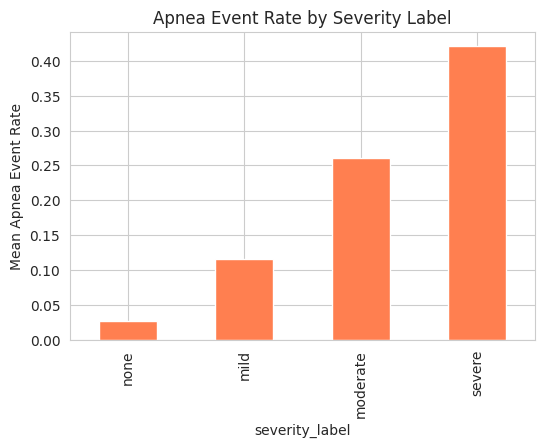


Demographics summary:
               age         bmi
count  219.000000  219.000000
mean    46.200913   27.315982
std     14.431610    5.090364
min     18.000000   16.000000
25%     36.000000   23.600000
50%     46.000000   27.300000
75%     56.000000   31.000000
max     84.000000   40.100000


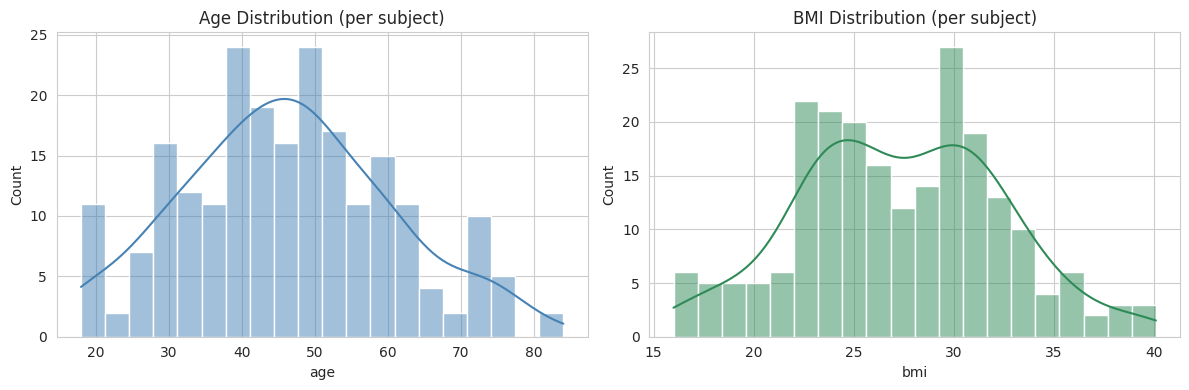

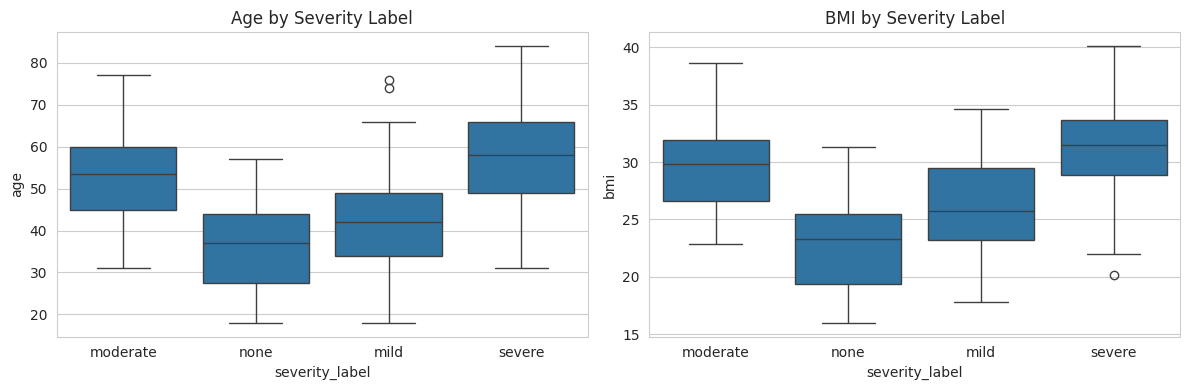


Descriptive statistics:
            acc_mean       acc_std       hr_mean        hr_std     spo2_mean  \
count  1.048575e+06  1.048575e+06  1.048575e+06  1.048575e+06  1.048575e+06   
mean   8.719752e+00  2.307106e+00  6.856226e+01  3.314694e+00  9.459990e+01   
std    6.995704e+00  2.376161e+00  1.031353e+01  2.519270e+00  3.300158e+00   
min    0.000000e+00  0.000000e+00  4.000000e+01  0.000000e+00  8.050000e+01   
25%    4.210000e+00  8.000000e-01  6.140000e+01  1.600000e+00  9.430000e+01   
50%    6.000000e+00  1.250000e+00  6.680000e+01  2.500000e+00  9.570000e+01   
75%    1.124000e+01  3.410000e+00  7.360000e+01  4.330000e+00  9.660000e+01   
max    4.072000e+01  1.229000e+01  1.222000e+02  1.512000e+01  1.000000e+02   

           spo2_min  
count  1.048575e+06  
mean   9.312774e+01  
std    4.221054e+00  
min    7.480000e+01  
25%    9.320000e+01  
50%    9.460000e+01  
75%    9.560000e+01  
max    9.990000e+01  


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

df = pd.read_csv("/content/sleep_apnea_synthetic_data.csv")

# 1. BASIC OVERVIEW
print("Shape:", df.shape)
print("\nColumn dtypes:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# 2. SUBJECT / NIGHT / EPOCH STRUCTURE
print("\nUnique subjects:", df["subject_id"].nunique())
print("Unique nights:", df["night_id"].nunique())
print("Nights per subject:\n", df.groupby("subject_id")["night_id"].nunique().describe())
print("Epochs per subject:\n", df.groupby("subject_id").size().describe())
print("Epochs per night:\n", df.groupby("night_id").size().describe())

# 3. TARGET LABEL DISTRIBUTION
print("\nSeverity label counts (row-level):")
print(df["severity_label"].value_counts())
print("\nSeverity label proportions (row-level):")
print(df["severity_label"].value_counts(normalize=True).round(3))

# Subject-level label (one label per subject, since it's likely constant per subject)
subject_label = df.groupby("subject_id")["severity_label"].first()
print("\nSeverity label counts (subject-level):")
print(subject_label.value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["severity_label"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Severity Label Distribution (row-level)")
axes[0].set_ylabel("Count")

subject_label.value_counts().plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Severity Label Distribution (subject-level)")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

# Sanity check: is severity_label constant within a subject?
inconsistent = df.groupby("subject_id")["severity_label"].nunique()
print("\nSubjects with more than 1 unique severity_label:", (inconsistent > 1).sum())

# 4. APNEA EVENT FLAG DISTRIBUTION
print("\nis_apnea_event counts:")
print(df["is_apnea_event"].value_counts())
print("Apnea event rate:", df["is_apnea_event"].mean().round(4))

plt.figure(figsize=(5, 4))
df["is_apnea_event"].value_counts().plot(kind="bar", color=["seagreen", "indianred"])
plt.title("Apnea Event Flag Distribution")
plt.xticks([0, 1], ["No Event", "Apnea Event"], rotation=0)
plt.show()

# Apnea rate by severity
apnea_by_severity = df.groupby("severity_label")["is_apnea_event"].mean().sort_values()
print("\nApnea event rate by severity label:\n", apnea_by_severity)

plt.figure(figsize=(6, 4))
apnea_by_severity.plot(kind="bar", color="coral")
plt.title("Apnea Event Rate by Severity Label")
plt.ylabel("Mean Apnea Event Rate")
plt.show()


# 5. DEMOGRAPHICS (age, bmi) — one row per subject
demo = df.groupby("subject_id")[["age", "bmi"]].first()
print("\nDemographics summary:\n", demo.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(demo["age"], bins=20, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Age Distribution (per subject)")
sns.histplot(demo["bmi"], bins=20, kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("BMI Distribution (per subject)")
plt.tight_layout()
plt.show()

# Age & BMI vs severity
demo_severity = df.groupby("subject_id")[["age", "bmi"]].first()
demo_severity["severity_label"] = subject_label

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=demo_severity, x="severity_label", y="age", ax=axes[0])
axes[0].set_title("Age by Severity Label")
sns.boxplot(data=demo_severity, x="severity_label", y="bmi", ax=axes[1])
axes[1].set_title("BMI by Severity Label")
plt.tight_layout()
plt.show()

# 6. NUMERIC FEATURE DISTRIBUTIONS
numeric_features = ["acc_mean", "acc_std", "hr_mean", "hr_std", "spo2_mean", "spo2_min"]

print("\nDescriptive statistics:\n", df[numeric_features].describe())

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), numeric_features):
    sns.histplot(df[col], bins=50, kde=True, ax=ax, color="teal")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

# Boxplots to spot outliers
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), numeric_features):
    sns.boxplot(y=df[col], ax=ax, color="lightcoral")
    ax.set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

# 7. FEATURE DISTRIBUTIONS BY SEVERITY LABEL
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.flatten(), numeric_features):
    sns.boxplot(data=df, x="severity_label", y=col, ax=ax)
    ax.set_title(f"{col} by Severity Label")
plt.tight_layout()
plt.show()

# Violin plots for a richer view of spo2 (often most discriminative for apnea)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.violinplot(data=df, x="severity_label", y="spo2_mean", ax=axes[0])
axes[0].set_title("SpO2 Mean by Severity")
sns.violinplot(data=df, x="severity_label", y="spo2_min", ax=axes[1])
axes[1].set_title("SpO2 Min by Severity")
plt.tight_layout()
plt.show()

# 8. CORRELATION ANALYSIS
corr_cols = numeric_features + ["age", "bmi", "is_apnea_event"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

# 9. TIME-SERIES VIEW: SIGNAL TRAJECTORY FOR A SAMPLE SUBJECT
sample_subject = df["subject_id"].iloc[0]
sample = df[df["subject_id"] == sample_subject].sort_values("epoch_index")

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(sample["epoch_index"], sample["hr_mean"], color="crimson")
axes[0].set_ylabel("HR mean")
axes[1].plot(sample["epoch_index"], sample["spo2_mean"], color="steelblue")
axes[1].set_ylabel("SpO2 mean")
axes[2].plot(sample["epoch_index"], sample["acc_mean"], color="seagreen")
axes[2].set_ylabel("Acc mean")
axes[3].plot(sample["epoch_index"], sample["is_apnea_event"], color="black")
axes[3].set_ylabel("Apnea Event")
axes[3].set_xlabel("Epoch Index")
fig.suptitle(f"Signal Trajectories — Subject {sample_subject} (severity: {sample['severity_label'].iloc[0]})")
plt.tight_layout()
plt.show()

# 10. CLASS IMBALANCE SUMMARY (useful before modeling)
print("\nClass imbalance ratio (row-level, max/min):")
vc = df["severity_label"].value_counts()
print((vc.max() / vc.min()).round(2))

print("\nClass imbalance ratio (subject-level, max/min):")
vc_sub = subject_label.value_counts()
print((vc_sub.max() / vc_sub.min()).round(2))